<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   User ID            500000 non-null  object 
 1   User Name          500000 non-null  object 
 2   Driver Name        500000 non-null  object 
 3   Car Condition      500000 non-null  object 
 4   Weather            500000 non-null  object 
 5   Traffic Condition  500000 non-null  object 
 6   key                500000 non-null  object 
 7   fare_amount        500000 non-null  float64
 8   pickup_datetime    500000 non-null  object 
 9   pickup_longitude   500000 non-null  float64
 10  pickup_latitude    500000 non-null  float64
 11  dropoff_longitude  499995 non-null  float64
 12  dropoff_latitude   499995 non-null  float64
 13  passenger_count    500000 non-null  int64  
 14  hour               500000 non-null  int64  
 15  day                500000 non-null  int64  
 16  mo

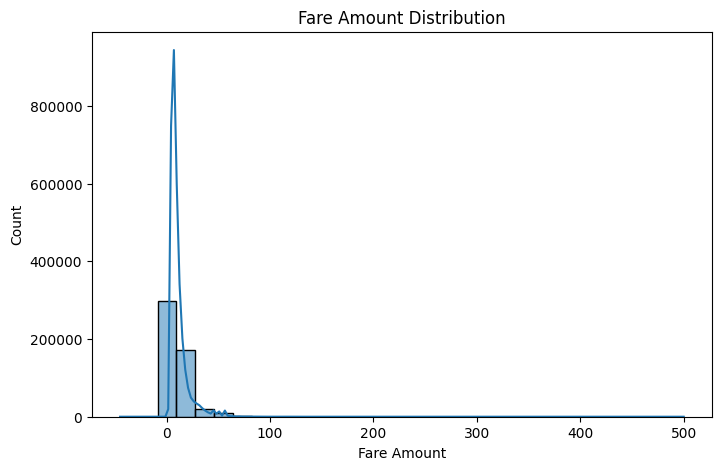

Missing Values:
 User ID              0
User Name            0
Driver Name          0
Car Condition        0
Weather              0
Traffic Condition    0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    5
dropoff_latitude     5
passenger_count      0
hour                 0
day                  0
month                0
weekday              0
year                 0
jfk_dist             5
ewr_dist             5
lga_dist             5
sol_dist             5
nyc_dist             5
distance             5
bearing              5
dtype: int64


In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("/Users/omarmedhat/Documents/Cellula ML/Week 6/Task/final_internship_data.csv")

# Display basic info
print(df.info())
print(df.describe())

# Visualize fare amount distribution
plt.figure(figsize=(8,5))
sns.histplot(df['fare_amount'], bins=30, kde=True)
plt.title("Fare Amount Distribution")
plt.xlabel("Fare Amount")
plt.ylabel("Count")
plt.show()

# Check for missing values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)


In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("/Users/omarmedhat/Documents/Cellula ML/Week 6/Task/final_internship_data.csv")

# Convert datetime column before handling missing values
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')

# Select only numeric columns for median imputation
numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Fill missing categorical values with 'Unknown'
categorical_cols = df.select_dtypes(include=['object']).columns
df[categorical_cols] = df[categorical_cols].fillna("Unknown")

# Ensure there are no null values left
print("Missing values after cleaning:\n", df.isnull().sum())


Missing values after cleaning:
 User ID              0
User Name            0
Driver Name          0
Car Condition        0
Weather              0
Traffic Condition    0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
hour                 0
day                  0
month                0
weekday              0
year                 0
jfk_dist             0
ewr_dist             0
lga_dist             0
sol_dist             0
nyc_dist             0
distance             0
bearing              0
dtype: int64


In [3]:
import os
import sys
import django

# Ensure the Django project path is set correctly
sys.path.append("/Users/omarmedhat/Documents/Cellula ML/Week 6/Task/django_Omar Medhat")

# Set Django settings
os.environ.setdefault("DJANGO_SETTINGS_MODULE", "myproject.settings")
django.setup()

print("Django environment loaded successfully!")


Django environment loaded successfully!


In [4]:
import os
import sys
import django

# Ensure the correct Django project path
sys.path.append("/Users/omarmedhat/Documents/Cellula ML/Week 6/Task/django_Omar Medhat")

# Set Django settings
os.environ.setdefault("DJANGO_SETTINGS_MODULE", "myproject.settings")
django.setup()

# Try importing RideData again
from myapp.models import RideData
print("RideData imported successfully!")


RideData imported successfully!


In [5]:
import os
import sys
import django
import pandas as pd
import asyncio
import nest_asyncio
from asgiref.sync import sync_to_async
from myapp.models import RideData

# Ensure the correct Django project path
sys.path.append("/Users/omarmedhat/Documents/Cellula ML/Week 6/Task/django_Omar Medhat")

# Set Django settings
os.environ.setdefault("DJANGO_SETTINGS_MODULE", "myproject.settings")
django.setup()

# Allow nested async calls in Jupyter
nest_asyncio.apply()

# Load the CSV file
df = pd.read_csv("/Users/omarmedhat/Documents/Cellula ML/Week 6/Task/final_internship_data.csv")

# Convert pickup_datetime column
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')

# Function to insert data synchronously
async def insert_data():
    for _, row in df.iterrows():
        await sync_to_async(RideData.objects.create)(
            user_id=row['User ID'],
            user_name=row['User Name'],
            driver_name=row['Driver Name'],
            car_condition=row['Car Condition'],
            weather=row['Weather'],
            traffic_condition=row['Traffic Condition'],
            fare_amount=row['fare_amount'],
            pickup_datetime=row['pickup_datetime'],
            pickup_longitude=row['pickup_longitude'],
            pickup_latitude=row['pickup_latitude'],
            dropoff_longitude=row['dropoff_longitude'],
            dropoff_latitude=row['dropoff_latitude'],
            distance=row['distance'],
            bearing=row['bearing']
        )
    print("Data successfully imported into the Django database!")

# Run the async function in Jupyter correctly
await insert_data()


/opt/anaconda3/envs/GPU/lib/python3.9/site-packages/django/db/models/fields/__init__.py:1595: RuntimeWarning: DateTimeField RideData.pickup_datetime received a naive datetime (2009-06-15 17:26:21) while time zone support is active.
  warnings.warn(
/opt/anaconda3/envs/GPU/lib/python3.9/site-packages/django/db/models/fields/__init__.py:1595: RuntimeWarning: DateTimeField RideData.pickup_datetime received a naive datetime (2010-01-05 16:52:16) while time zone support is active.
  warnings.warn(
/opt/anaconda3/envs/GPU/lib/python3.9/site-packages/django/db/models/fields/__init__.py:1595: RuntimeWarning: DateTimeField RideData.pickup_datetime received a naive datetime (2011-08-18 00:35:00) while time zone support is active.
  warnings.warn(
/opt/anaconda3/envs/GPU/lib/python3.9/site-packages/django/db/models/fields/__init__.py:1595: RuntimeWarning: DateTimeField RideData.pickup_datetime received a naive datetime (2012-04-21 04:30:42) while time zone support is active.
  warnings.warn(
/opt

CancelledError: 

In [6]:

from myapp.models import RideData

# Example Query: Get rides with high fares
high_fare_rides = RideData.objects.filter(fare_amount__gte=50)
print(high_fare_rides)

# Example Query: Get rides during a storm
stormy_rides = RideData.objects.filter(weather="stormy")
print(stormy_rides)


SynchronousOnlyOperation: You cannot call this from an async context - use a thread or sync_to_async.

In [7]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Select features
X = df[['distance', 'bearing']]
y = df['fare_amount']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate Model
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
print("Mean Absolute Error:", mae)


ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values